In [2]:
! wget "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+pscomppars&format=csv" -O ps_data.csv

--2026-02-18 19:00:20--  https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+pscomppars&format=csv
Resolving exoplanetarchive.ipac.caltech.edu (exoplanetarchive.ipac.caltech.edu)... 134.4.25.48
Connecting to exoplanetarchive.ipac.caltech.edu (exoplanetarchive.ipac.caltech.edu)|134.4.25.48|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘ps_data.csv’

ps_data.csv             [               <=>  ]  73.60M  16.5MB/s    in 5.4s    

2026-02-18 19:00:35 (13.6 MB/s) - ‘ps_data.csv’ saved [77177625]



# Exercise 3: Transits

# Part 1
Here we will explore the demographics of transiting planets in the Nasa exoplanet archive in more detail.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
# load the data in as a pandas dataframe
df = pd.read_csv('ps_data.csv',header=0,sep=',')

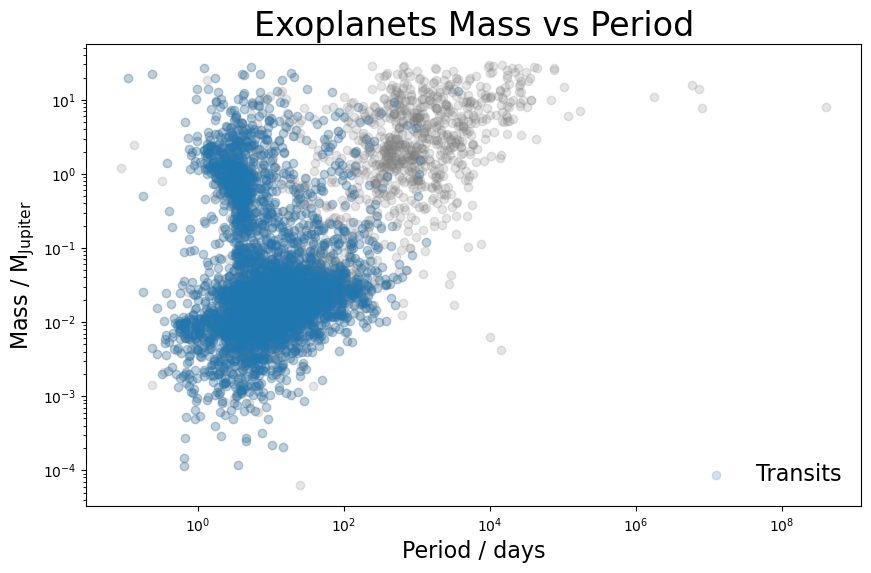

In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(df['pl_orbper'], df['pl_bmassj'], color='grey', alpha=0.2)

planets = df.loc[df["discoverymethod"]=='Transit']
plt.scatter(planets['pl_orbper'], planets['pl_bmassj'], alpha=0.2, label='Transits')

plt.title("Exoplanets Mass vs Period", fontsize=24)
plt.ylabel(r"Mass / M$_{\rm Jupiter}$", fontsize=16)
plt.xlabel("Period / days", fontsize=16)
plt.yscale("log")
plt.xscale("log")
plt.legend(fontsize=16, frameon=False, loc='lower right')

# Part 2
Now we will eaxmine the transit observation method using a lightcurve fitting package called Batman.

In [8]:
import batman
import astropy.constants as const
import astropy.units as u
import matplotlib.cm as cm
import h5py
from astropy.modeling.fitting import LevMarLSQFitter, LinearLSQFitter
from astropy.modeling.models import Linear1D

In [11]:
# example batman model
params = batman.TransitParams()       #object to store transit parameters
params.t0 = 0.                        #time of inferior conjunction
params.per = 1.51087081                      #orbital period
params.rp = 0.09689*const.R_jup/(0.117*const.R_sun)                   #planet radius (in units of stellar radii)
params.a = 0.01111*u.AU/(0.117*const.R_sun)                       #semi-major axis (in units of stellar radii)
params.inc = 87.                      #orbital inclination (in degrees)
params.ecc = 0.                       #eccentricity
params.w = 90.                        #longitude of periastron (in degrees)
params.limb_dark = "quadratic"        #limb darkening model
params.u = [0.1, 0.]      #limb darkening coefficients [u1, u2, u3, u4]

t = np.linspace(-0.01, 0.01, 1000)  #times at which to calculate light curve
m = batman.TransitModel(params, t)    #initializes model

Text(0.5, 0, 'Time / days')

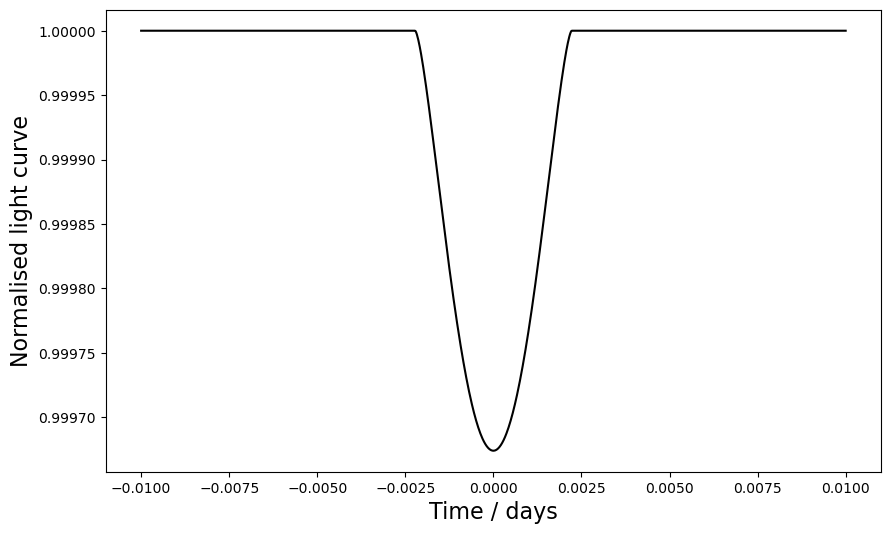

In [12]:
plt.figure(figsize=(10, 6))

light_curve = m.light_curve(params) 

plt.plot(t, light_curve, "black")
plt.ylabel("Normalised light curve", fontsize=16)
plt.xlabel("Time / days", fontsize=16)

# Part 3

Now we will explore the transit of WASP-39b as observed by the James Webb Space Telescope (JWST).

In [116]:
! wget https://share.phys.ethz.ch/~ipa/exoplanet_lecture_FS24/firefly_normalized_specphot.h5

--2026-02-18 20:11:06--  https://share.phys.ethz.ch/~ipa/exoplanet_lecture_FS24/firefly_normalized_specphot.h5
Resolving share.phys.ethz.ch (share.phys.ethz.ch)... 129.132.80.27, 2001:67c:10ec:3dc4::39
Connecting to share.phys.ethz.ch (share.phys.ethz.ch)|129.132.80.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88066048 (84M)
Saving to: ‘firefly_normalized_specphot.h5’

firefly_normalized_ 100%[===================>]  83.99M   154MB/s    in 0.5s    

2026-02-18 20:11:07 (154 MB/s) - ‘firefly_normalized_specphot.h5’ saved [88066048/88066048]



In [12]:
# load data
filename = "firefly_normalized_specphot.h5"
with h5py.File(filename, "r") as file:
    print(file.keys())
    data = file["specphot"][()]

<KeysViewHDF5 ['specphot']>


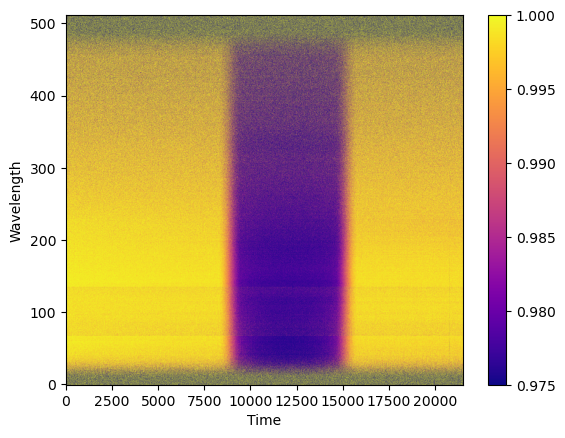

In [13]:
# Visualise the data
plt.figure()
plt.imshow(data, aspect="auto", origin="lower", vmax=1., vmin=0.975, cmap="plasma")
plt.xlabel('Time')
plt.ylabel('Pixel')
plt.colorbar()

Text(0.5, 0, 'Time / days')

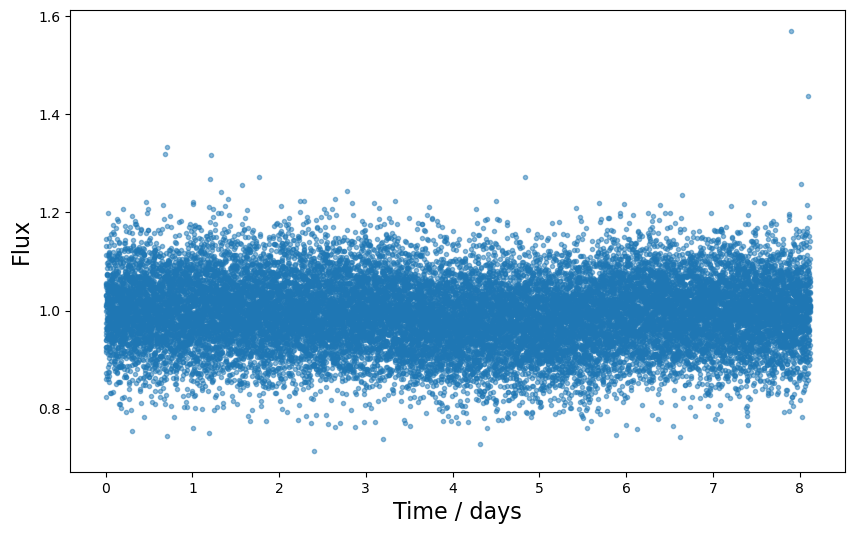

In [18]:
plt.figure(figsize=(10, 6))

time = np.arange(data.shape[1])*1.36/3600

signal_white_light = data[:, :].mean(axis=0)

plt.plot(time, signal_white_light, ".", alpha=0.5) # white light curve 
plt.ylabel("Normalised flux", fontsize=16)
plt.xlabel("Time / days", fontsize=16)